## 바이오 빅데이터 분석 (2)
### 회귀 분석 실습: CCLE gene expression 기반 CTRP drug response 예측

이 노트북은 CCLE 세포주 유전자 발현 데이터와 CTRP 약물 반응 데이터를 사용해 회귀 모델을 학습하고 평가하는 실습용 자료입니다. 먼저 단일 화학항암제(`CLOFARABINE`)로 회귀 모델의 기본 흐름을 익힌 뒤, 여러 화학항암제와 표적항암제의 예측 성능을 비교합니다.

**학습 목표**
- 유전자 발현 행렬과 약물 반응값(AUC/EC50)을 회귀 문제로 연결한다.
- train/test split과 cross-validation의 차이를 이해한다.
- PCC, SCC, R2, MAE, RMSE로 회귀 성능을 평가한다.
- ElasticNet, Ridge, Lasso, RandomForest 모델을 비교한다.
- 화학항암제와 표적항암제의 반응 예측 성능 차이를 해석한다.


### 0. 실행 환경

로컬 폴더에 있는 `data_CCLE_CTRPv2/*.csv` 파일을 우선 사용합니다. 로컬 CSV가 없고 Colab 등에서 실행하는 경우에는 `mlbi-lab`의 `load_data('ccle-ctrpv2')`를 사용할 수 있습니다.


In [ ]:
# Colab에서 로컬 CSV가 없을 때만 실행하세요.
# !pip install mlbi-lab
# !pip install xgboost

In [ ]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

from sklearn import linear_model as lm
from sklearn import metrics as met
from sklearn import model_selection as mod_sel
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 5
sns.set_theme(style='whitegrid', context='notebook')


/mnt/HDD2/Google_drive/PyPI_Git_Publish/pub_mlbi_lab/src/mlbi/datasets.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### 1. 데이터 로드

사용 데이터는 다음 5개입니다.

- `gene_expression`: 세포주 x 유전자 발현 행렬
- `auc`: 세포주 x 약물 AUC 반응 행렬
- `ec50`: 세포주 x 약물 EC50 반응 행렬
- `drug_info`: 약물 메타데이터
- `cellline_info`: 세포주 메타데이터


In [2]:
def load_ccle_ctrpv2(base_dir='data_CCLE_CTRPv2'):
    """Load CCLE/CTRPv2 data from local CSV files, with mlbi-lab fallback."""
    base = Path(base_dir)
    files = {
        'gene_expression': base / 'ccle_ctrpv2_gene_exp.csv',
        'cellline_info': base / 'ccle_ctrpv2_cellline_info.csv',
        'auc': base / 'ccle_ctrpv2_auc.csv',
        'ec50': base / 'ccle_ctrpv2_ec50.csv',
        'drug_info': base / 'ccle_ctrpv2_drug_info.csv',
        'mutation_info': base / 'ccle_ctrpv2_mutation_info.csv',
    }

    if all(path.exists() for path in files.values()):
        return {key: pd.read_csv(path, index_col=0) for key, path in files.items()}

    try:
        from mlbi.data import load_data
        return load_data('ccle-ctrpv2')
    except Exception as exc:
        raise FileNotFoundError(
            'Local CSV files were not found and mlbi-lab fallback failed. '
            'Check data_CCLE_CTRPv2/ or install mlbi-lab.'
        ) from exc


data = load_ccle_ctrpv2()
data.keys()


dict_keys(['gene_expression', 'cellline_info', 'auc', 'ec50', 'drug_info', 'mutation_info'])

In [3]:
df_gexp = data['gene_expression']
df_cl_info = data['cellline_info']
df_auc = data['auc']
df_ec50 = data['ec50']
df_drug_info = data['drug_info']

print('gene expression:', df_gexp.shape)
print('cell line info :', df_cl_info.shape)
print('AUC            :', df_auc.shape)
print('EC50           :', df_ec50.shape)
print('drug info      :', df_drug_info.shape)


gene expression: (826, 19177)
cell line info : (826, 27)
AUC            : (826, 545)
EC50           : (826, 545)
drug info      : (545, 11)


#### Data source

Depmap portal:  https://depmap.org/portal/

    1. Cell line Gene expression (matrix)
    2. Cell line information
    3. Mutation information
    4. Copy numver variation

Cancer Therapeutic Response Portal: https://portals.broadinstitute.org/ctrp/

    5. Drug response for CCLE cell lines (EC50, AUC)
    
참고: 약물반응지표: EC50과 AUC https://royalsocietypublishing.org/doi/10.1098/rstb.2018.0226

In [ ]:
df_drug_info

In [ ]:
df_mutation_info = data['mutation_info']
df_mutation_info.head()

In [ ]:
df_mutation_info.columns

In [ ]:
b = (df_mutation_info["Hugo_Symbol"] == "EGFR")
df_mutation_info.loc[b,"Protein_Change"].value_counts()

### 2. 데이터 탐색

먼저 세포주 계통(lineage), 약물 표적, 결측값을 확인합니다. 이후 실습에서는 화학항암제와 표적항암제를 나누어 성능을 비교하므로, 두 약물군의 후보 목록과 샘플 수를 함께 살펴봅니다.


In [ ]:
display(df_gexp.iloc[:5, :8])
display(df_auc.iloc[:5, :8])
display(df_drug_info.head())


In [ ]:
print('Gene expression missing values:', int(df_gexp.isnull().sum().sum()))
print('AUC missing values            :', int(df_auc.isnull().sum().sum()))
print('EC50 missing values           :', int(df_ec50.isnull().sum().sum()))


In [ ]:
if 'lineage' in df_cl_info.columns:
    display(df_cl_info['lineage'].value_counts().head(15))

if 'gene_symbol_of_protein_target' in df_drug_info.columns:
    display(df_drug_info['gene_symbol_of_protein_target'].value_counts().head(15))


In [ ]:
df_cl_info.columns

#### 몇가지 표적항암제 확인

In [ ]:
tinib_mask = df_drug_info['cpd_name'].astype(str).str.endswith('TINIB', na=False)
tinib_drugs = df_drug_info.loc[tinib_mask].index.intersection(df_auc.columns).tolist()
print(f'Number of TINIB drugs in AUC matrix: {len(tinib_drugs)}')
display(tinib_drugs[:20])


#### 화학항암제 후보 확인

아래 약물들은 DNA damage, topoisomerase, microtubule, platinum 계열 등 전통적인 화학항암제에 가까운 후보입니다. 이 데이터에서는 이런 약물들이 유전자 발현 기반 회귀 예측에서 비교적 좋은 성능을 보이는 경우가 많아서, 이후 실습의 기본 타깃으로 사용합니다.


In [ ]:
chemo_drug_candidates = [
    'CLOFARABINE',
    'CYTARABINE HYDROCHLORIDE',
    'DECITABINE',
    'PACLITAXEL',
    'DOCETAXEL',
    'DOXORUBICIN',
    'GEMCITABINE',
    'TOPOTECAN',
    'ETOPOSIDE',
    'TENIPOSIDE',
    'CARBOPLATIN',
    'OXALIPLATIN',
    'VINCRISTINE',
]
chemo_drug_candidates = [drug for drug in chemo_drug_candidates if drug in df_auc.columns]

chemo_summary = df_drug_info.reindex(chemo_drug_candidates)[[
    'cpd_name',
    'target_or_activity_of_compound',
    'gene_symbol_of_protein_target',
    'inclusion_rationale',
]].copy()
chemo_summary['n_AUC_samples'] = df_auc[chemo_drug_candidates].notna().sum()
chemo_summary = chemo_summary.sort_values('n_AUC_samples', ascending=False)
chemo_summary


#### 표적항암제 후보 요약

비교용으로 `TINIB` 계열 표적항암제 몇 가지도 함께 정리합니다. 이후 실습에서 화학항암제 후보와 표적항암제 후보의 예측 성능을 비교해보면, 약물 작용기전과 반응 예측 난이도의 차이를 관찰할 수 있습니다.


In [ ]:
targeted_drug_candidates = [
    'AFATINIB',
    'AXITINIB',
    'BOSUTINIB',
    'CABOZANTINIB',
    'CRIZOTINIB',
    'DASATINIB',
    'ERLOTINIB',
    'GEFITINIB',
    'LAPATINIB',
    'NERATINIB',
    'SUNITINIB',
]
targeted_drug_candidates = [drug for drug in targeted_drug_candidates if drug in df_auc.columns]

targeted_summary = df_drug_info.reindex(targeted_drug_candidates)[[
    'cpd_name',
    'gene_symbol_of_protein_target',
    'target_or_activity_of_compound',
    'inclusion_rationale',
]].copy()
targeted_summary['n_AUC_samples'] = df_auc[targeted_drug_candidates].notna().sum()
targeted_summary = targeted_summary.sort_values('n_AUC_samples', ascending=False)
targeted_summary


### 3. 전처리

유전자 발현값은 오른쪽으로 긴 분포를 갖는 경우가 많으므로 `log10(x + 1)` 변환을 적용합니다. 실습 속도를 위해 기본값은 분산이 큰 유전자 3,000개만 사용합니다. 전체 유전자를 사용하려면 다음 코드 셀에서 `TOP_N_GENES = None`으로 바꾸면 됩니다.


Features used for modeling: 3000


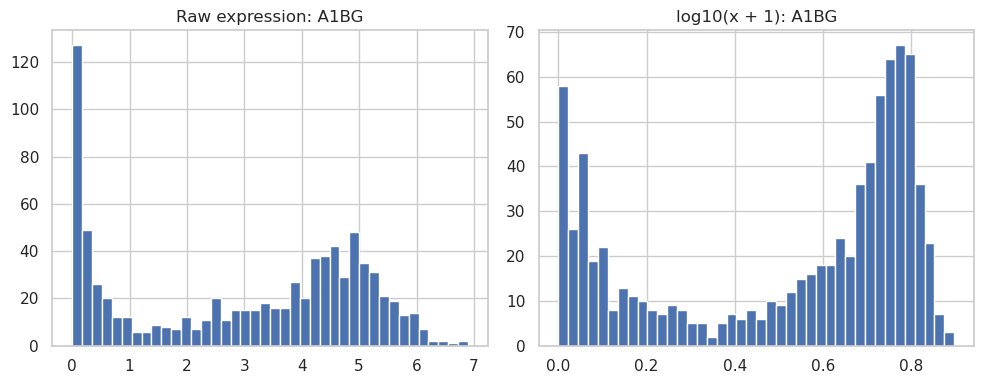

In [4]:
df_log_gexp = np.log10(df_gexp + 1)

# 전체 유전자를 모두 쓰면 일부 실습 환경에서 시간이 오래 걸릴 수 있습니다.
# 분산이 큰 유전자만 선택해 빠른 실습용 feature matrix를 만듭니다.
# 더 정밀한 분석을 원하면 TOP_N_GENES = None 으로 바꾸세요.
TOP_N_GENES = 3000
if TOP_N_GENES is None or TOP_N_GENES >= df_log_gexp.shape[1]:
    df_feature = df_log_gexp.copy()
else:
    top_genes = df_log_gexp.var(axis=0).sort_values(ascending=False).head(TOP_N_GENES).index
    df_feature = df_log_gexp.loc[:, top_genes].copy()

print('Features used for modeling:', df_feature.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_gexp.iloc[:, 0].hist(bins=40, ax=axes[0])
axes[0].set_title(f'Raw expression: {df_gexp.columns[0]}')
df_log_gexp.iloc[:, 0].hist(bins=40, ax=axes[1])
axes[1].set_title(f'log10(x + 1): {df_gexp.columns[0]}')
plt.tight_layout()


### 4. 단일 약물 AUC 회귀 문제 만들기

`target`을 바꾸면 다른 항암제에 대해 같은 분석을 반복할 수 있습니다. 기본값은 화학항암제 후보 중 예측 성능이 비교적 잘 나오는 약물로 둡니다. 이때 `TOP_N_GENES`로 선택된 feature에 더해, AUC matrix에 포함된 모든 compound 중 `df_drug_info['gene_symbol_of_protein_target']`에 valid protein target이 정의된 유전자들을 항상 feature matrix에 포함합니다. 이렇게 하면 표적항암제 실습에서 중요한 표적 유전자가 우연히 빠지는 것을 막을 수 있습니다.


In [ ]:
target = 'DECITABINE'
response_table = df_auc

if target not in response_table.columns:
    raise ValueError(f'{target} is not available. Try one of: {list(response_table.columns[:10])}')


def parse_target_genes(drug_name, drug_info=df_drug_info):
    if drug_name not in drug_info.index or 'gene_symbol_of_protein_target' not in drug_info.columns:
        return []

    genes = drug_info.loc[drug_name, 'gene_symbol_of_protein_target']
    if pd.isna(genes):
        return []

    return [gene.strip() for gene in str(genes).split(';') if gene.strip()]


def get_all_valid_target_genes(drug_info=df_drug_info, response_table=df_auc, expression_table=df_log_gexp):
    valid_drugs = drug_info.index.intersection(response_table.columns)
    target_values = drug_info.loc[valid_drugs, 'gene_symbol_of_protein_target'].dropna()

    target_genes = []
    for genes in target_values:
        target_genes.extend([gene.strip() for gene in str(genes).split(';') if gene.strip()])

    unique_target_genes = sorted(set(target_genes))
    return [gene for gene in unique_target_genes if gene in expression_table.columns]


y_raw = response_table[target]
valid_mask = y_raw.notna() & np.isfinite(y_raw)

current_target_genes = parse_target_genes(target)
all_valid_target_genes = get_all_valid_target_genes()
target_genes_to_add = [gene for gene in all_valid_target_genes if gene not in df_feature.columns]

X_df = pd.concat(
    [
        df_feature.loc[valid_mask],
        df_log_gexp.loc[valid_mask, target_genes_to_add],
    ],
    axis=1,
).copy()
y = y_raw.loc[valid_mask].astype(float).copy()
info_sel = df_cl_info.reindex(X_df.index)

print('Target drug:', target)
print('Current drug target genes:', current_target_genes if current_target_genes else 'Not available')
print('All valid target genes in expression:', len(all_valid_target_genes))
print('Target genes added to X_df:', len(target_genes_to_add))
print('Current target genes in X_df:', [gene for gene in current_target_genes if gene in X_df.columns])
print('Samples    :', X_df.shape[0])
print('Features   :', X_df.shape[1])
print('y range    :', (float(y.min()), float(y.max())))


In [ ]:
plt.figure(figsize=(5, 3.5))
plt.hist(y, bins=40, edgecolor='white')
plt.xlabel(f'{target} AUC')
plt.ylabel('Number of cell lines')
plt.title('Drug response distribution')
plt.tight_layout()


### 5. 평가 함수 만들기

회귀 성능은 한 가지 지표만 보면 놓치는 부분이 있습니다.

- **PCC**: 실제값과 예측값의 선형 상관
- **SCC**: 순위 기반 상관
- **R2**: 설명된 분산 비율
- **MAE/RMSE**: 예측 오차의 크기


In [ ]:
def regression_scores(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(np.unique(y_true)) < 2 or len(np.unique(y_pred)) < 2:
        pcc = np.nan
        scc = np.nan
    else:
        pcc = pearsonr(y_true, y_pred)[0]
        scc = spearmanr(y_true, y_pred)[0]

    return {
        'PCC': pcc,
        'SCC': scc,
        'R2': met.r2_score(y_true, y_pred),
        'MAE': met.mean_absolute_error(y_true, y_pred),
        'RMSE': float(np.sqrt(met.mean_squared_error(y_true, y_pred))),
    }


def plot_actual_vs_predicted(y_true, y_pred, title='Actual vs predicted'):
    scores = regression_scores(y_true, y_pred)
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))

    plt.figure(figsize=(4.5, 4.5))
    plt.scatter(y_true, y_pred, alpha=0.75, s=32)
    plt.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title)
    plt.text(
        0.04, 0.96,
        f"PCC={scores['PCC']:.3f}\nR2={scores['R2']:.3f}\nRMSE={scores['RMSE']:.3f}",
        transform=plt.gca().transAxes,
        va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='lightgray', alpha=0.85),
    )
    plt.tight_layout()
    return scores


### 6. Train/Test split: ElasticNet 기본 모델

ElasticNet은 L1(Lasso)과 L2(Ridge) 규제를 함께 사용하는 선형 회귀 모델입니다. 유전자 수가 샘플 수보다 훨씬 많은 데이터에서 기본 모델로 쓰기 좋습니다.


#### 선형 회귀 모형 그림

<div style="display:flex; gap:24px; align-items:flex-start;">
  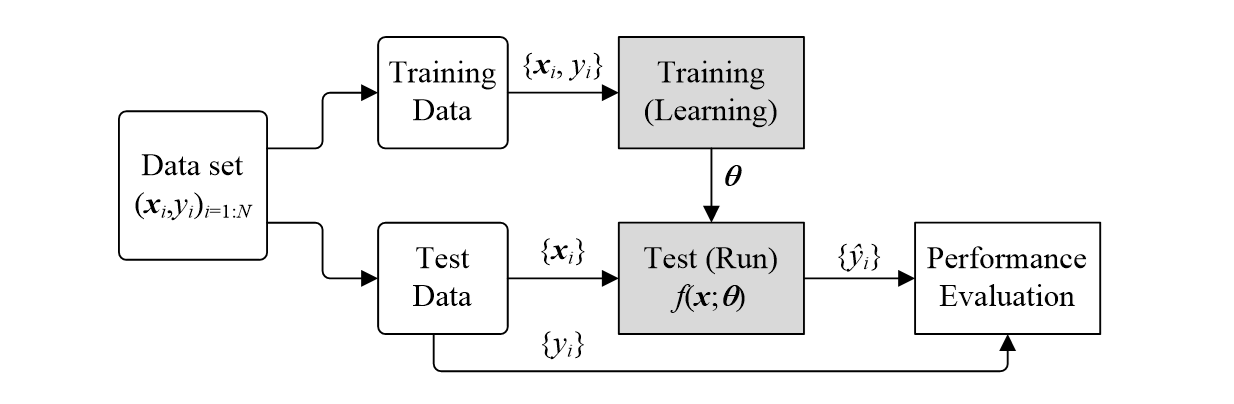
</div>
  
<br>
<div style="display:flex; gap:24px; align-items:flex-start;">
  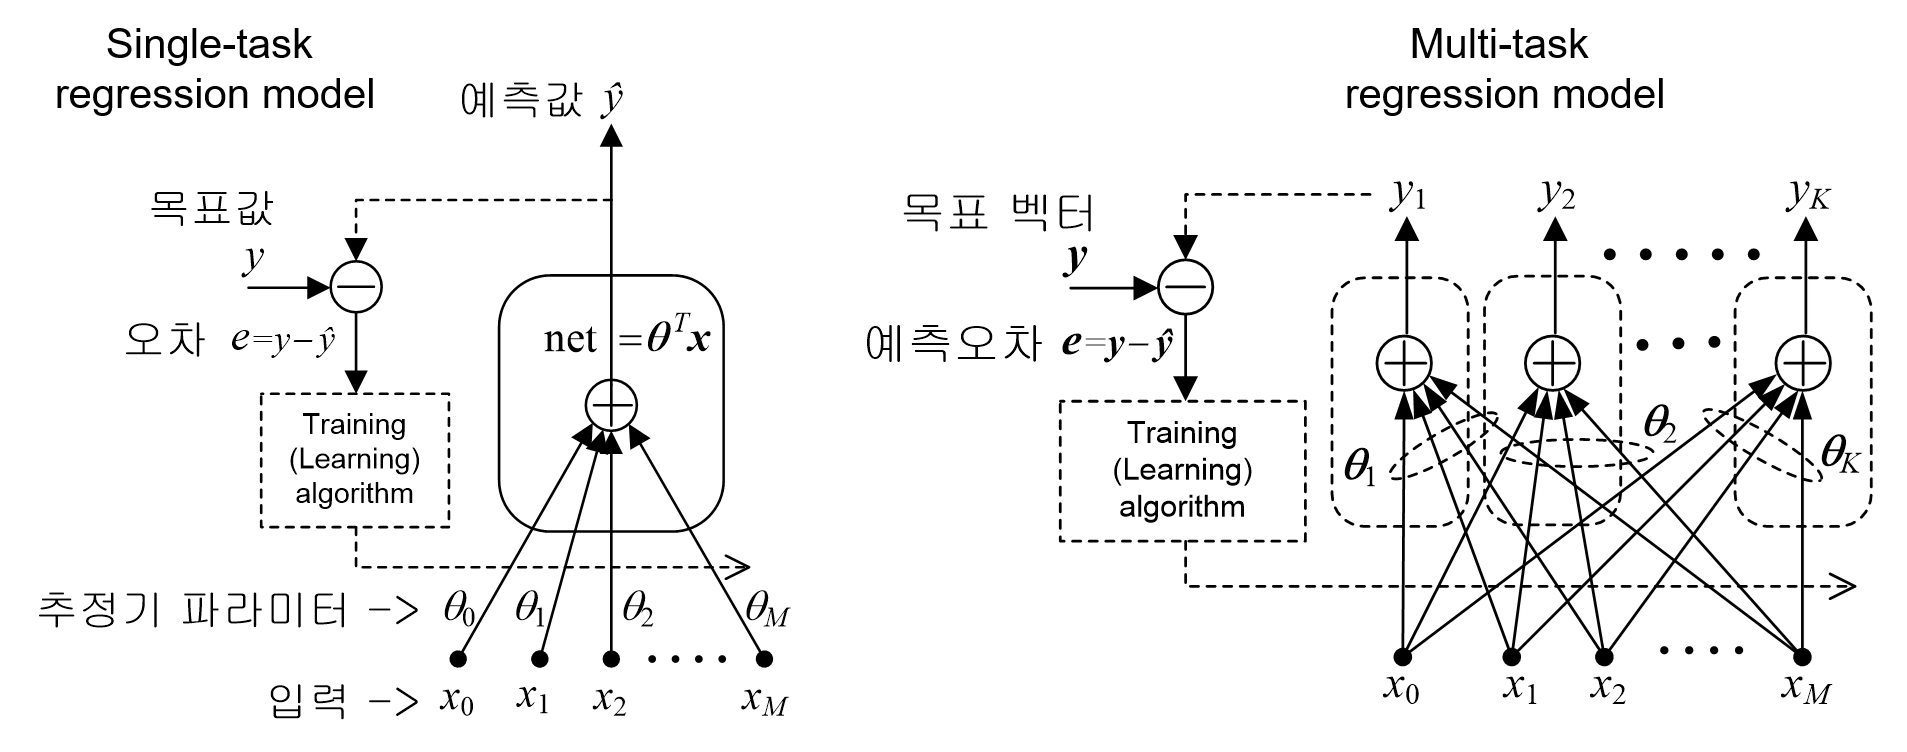  
</div>


## Model:

### (Binary) Linear regression with $l_1$ and $l_2$ penalty (ElasticNet)
model description: https://scikit-learn.org/stable/modules/linear_model.html#
<br>
model usage: https://scikit-learn.org/stable/modules/linear_model.html#elastic-net

#### Model: $$ \hat{\bf{y}}\left( \bf{x} ; \boldsymbol{\theta} \right) = {\bf{x}}^T_i {\boldsymbol{\theta}} + c $$
#### Cost to minimize (OLS): $$ \min_{{\boldsymbol{\theta}},c} \frac{1}{2n} \| \bf{y}-\hat{\bf{y}}\left( \bf{x} ; \boldsymbol{\theta} \right) \|^2 $$
#### Cost to minimize (ElasticNet): $$ \min_{{\boldsymbol{\theta}},c} \frac{1}{2n} \| \bf{y}-\hat{\bf{y}}\left( \bf{x} ; \boldsymbol{\theta} \right) \|^2 + \alpha \left( \frac{1-\rho}{2} {\boldsymbol{\theta}}^T{\boldsymbol{\theta}} + \rho \| {\boldsymbol{\theta}} \|_1 \right) $$
where
1. $\alpha$ controls the relative weight between RSS (1st term) and penaties (2nd and 3rd terms).
2. $\rho$ controls the relative weight between $l_1$ and $l_2$ penalty. $\rho = 1$ corresponds to LASSO while $\rho=0$ to Ridge.
3. $C \rightarrow \infty $ means no penalty.
<br>


In [ ]:
X_train, X_test, y_train, y_test = mod_sel.train_test_split(
    X_df, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

elastic_net = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.ElasticNet(alpha=0.02, l1_ratio=1.0, max_iter=5000, random_state=RANDOM_STATE)),
]) 
## alpha = 0 => OLS
## alpha != 0 and l1_ratio = 1 => LASSO
## alpha != 0 and l1_ratio = 0 => Ridge


elastic_net.fit(X_train, y_train)
y_train_pred = elastic_net.predict(X_train)
y_test_pred = elastic_net.predict(X_test)

train_scores = regression_scores(y_train, y_train_pred)
test_scores = regression_scores(y_test, y_test_pred)

pd.DataFrame([train_scores, test_scores], index=['train', 'test'])


In [ ]:
plot_actual_vs_predicted(y_train, y_train_pred, title=f'{target} AUC: ElasticNet training set')
plot_actual_vs_predicted(y_test, y_test_pred, title=f'{target} AUC: ElasticNet test set')


#### 실습 A

아래 값을 바꿔가며 test set 성능이 어떻게 달라지는지 확인하세요.

- `alpha`: 규제 강도
- `l1_ratio`: 1이면 Lasso, 0이면 Ridge에 가까움
- `test_size`: 테스트 데이터 비율


In [ ]:
# 실습 A: 하이퍼파라미터를 바꿔보세요.
practice_alpha = 0.02
practice_l1_ratio = 1.0
practice_test_size = 0.2

X_train, X_test, y_train, y_test = mod_sel.train_test_split(
    X_df, y, test_size=practice_test_size, random_state=RANDOM_STATE, shuffle=True
)

practice_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.ElasticNet(
        alpha=practice_alpha,
        l1_ratio=practice_l1_ratio,
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])

practice_model.fit(X_train, y_train)
y_train_pred = practice_model.predict(X_train)
y_test_pred = practice_model.predict(X_test)

practice_scores = pd.DataFrame(
    [
        regression_scores(y_train, y_train_pred),
        regression_scores(y_test, y_test_pred),
    ],
    index=['train', 'test'],
)

practice_scores.loc['gap(train-test)'] = practice_scores.loc['train'] - practice_scores.loc['test']
practice_scores


In [ ]:
r2_gap = practice_scores.loc['gap(train-test)', 'R2']
rmse_gap = practice_scores.loc['gap(train-test)', 'RMSE']

if r2_gap > 0.20 and rmse_gap < 0:
    overfit_message = 'Train 성능이 test 성능보다 많이 높습니다. 과적합 가능성이 큽니다.'
elif r2_gap > 0.10:
    overfit_message = 'Train 성능이 test 성능보다 다소 높습니다. 약한 과적합 가능성을 확인해보세요.'
else:
    overfit_message = 'Train과 test 성능 차이가 크지 않습니다. 이 분할에서는 과적합 신호가 뚜렷하지 않습니다.'

print(overfit_message)
print(f"R2 gap = {r2_gap:.3f}, RMSE gap(train-test) = {rmse_gap:.3f}")


### 7. Cross-validation

Train/test split은 한 번의 분할에 결과가 영향을 받을 수 있습니다. Cross-validation은 데이터를 여러 fold로 나누어 더 안정적인 일반화 성능을 추정합니다.


#### 교차검증 절차 모식도

<div style="display:flex; gap:24px; align-items:flex-start;">
  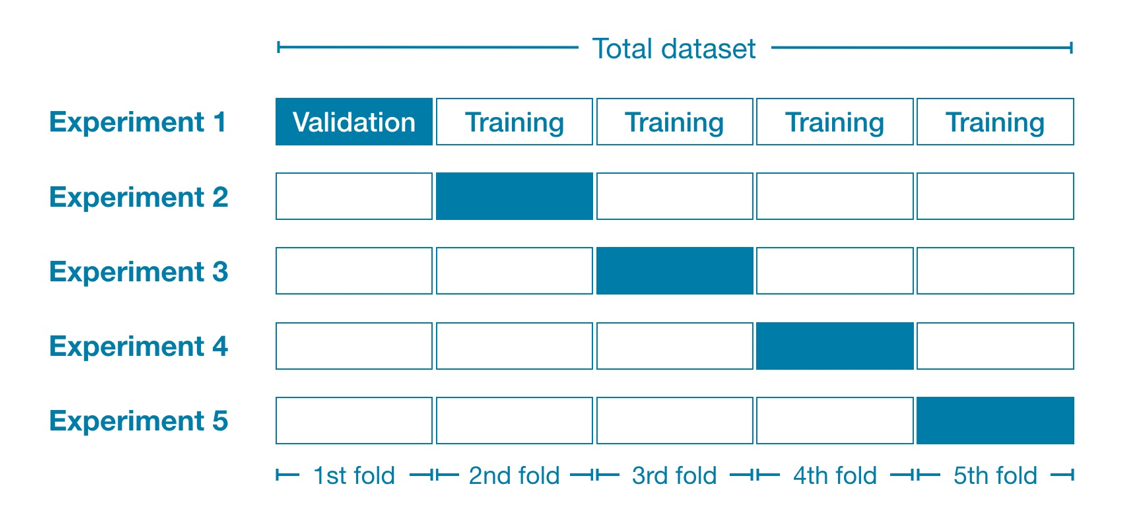  
</div>


In [ ]:
NCV = 5
cv = mod_sel.KFold(n_splits=NCV, shuffle=True, random_state=RANDOM_STATE)

cv_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.ElasticNet(alpha=0.02, l1_ratio=1.0, max_iter=5000, random_state=RANDOM_STATE)),
])

y_pred_cv = mod_sel.cross_val_predict(cv_model, X_df, y, cv=cv, n_jobs=-1)
cv_scores = regression_scores(y, y_pred_cv)
pd.Series(cv_scores, name=f'{NCV}-fold CV')


In [ ]:
plot_actual_vs_predicted(y, y_pred_cv, title=f'{target} AUC: ElasticNet {NCV}-fold CV')


### 8. GridSearchCV로 하이퍼파라미터 최적화

여기서는 현재 선택한 단일 약물(`target`)에 대해 `alpha`와 `l1_ratio` 후보를 탐색합니다. 뒤쪽 과제에서는 이 아이디어를 확장해, 약물마다 별도로 GridSearchCV를 수행한 뒤 화학항암제와 표적항암제의 성능을 비교합니다.


In [ ]:
base_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.ElasticNet(max_iter=5000, random_state=RANDOM_STATE)),
])

param_grid = {
    'model__alpha': [0.001, 0.005, 0.01, 0.02, 0.05, 0.1],
    'model__l1_ratio': [0.2, 0.5, 0.8, 1.0],
}

gs = mod_sel.GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='r2',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

gs.fit(X_df, y)
print('Best CV R2:', round(gs.best_score_, 3))
print('Best params:', gs.best_params_)


In [ ]:
best_model = gs.best_estimator_
y_pred_best_cv = mod_sel.cross_val_predict(best_model, X_df, y, cv=cv, n_jobs=-1)
pd.Series(regression_scores(y, y_pred_best_cv), name='Best ElasticNet CV')


In [ ]:
best_model

In [ ]:
plot_actual_vs_predicted(y, y_pred_best_cv, title=f'{target} AUC: ElasticNet {NCV}-fold CV')


### 9. 여러 약물에 반복 적용하기

같은 ElasticNet 설정을 여러 약물에 반복 적용해 빠르게 성능을 비교합니다. 이 결과는 약물별 예측 난이도의 대략적인 차이를 보는 용도입니다. 더 공정한 비교를 위해서는 약물마다 하이퍼파라미터를 따로 최적화해야 하며, 그 작업은 과제에서 수행합니다.


In [ ]:
def prepare_drug_response(drug, response_table=df_auc, feature_table=df_feature, min_samples=50):
    if drug not in response_table.columns:
        raise ValueError(f'{drug} not found in response table.')

    y_raw = response_table[drug]
    valid = y_raw.notna() & np.isfinite(y_raw)
    if valid.sum() < min_samples:
        return None, None

    X_drug = feature_table.loc[valid].copy()
    y_drug = y_raw.loc[valid].astype(float).copy()
    return X_drug, y_drug


def evaluate_drug_cv(drug, model, response_table=df_auc, feature_table=df_feature, cv=cv, min_samples=50):
    X_drug, y_drug = prepare_drug_response(
        drug, response_table=response_table, feature_table=feature_table, min_samples=min_samples
    )
    if X_drug is None:
        return None

    y_pred = mod_sel.cross_val_predict(model, X_drug, y_drug, cv=cv, n_jobs=-1)
    result = regression_scores(y_drug, y_pred)
    result.update({'drug': drug, 'n_samples': len(y_drug)})
    return result


In [ ]:
drugs_to_test = [
    'CLOFARABINE',
    'CYTARABINE HYDROCHLORIDE',
    'DECITABINE',
    'DOXORUBICIN',
    'TOPOTECAN',
    'ETOPOSIDE',
    'PACLITAXEL',
    'CARBOPLATIN',
    'VINCRISTINE',
]
drugs_to_test = [drug for drug in drugs_to_test if drug in df_auc.columns]

default_enet = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.ElasticNet(alpha=0.1, l1_ratio=1.0, max_iter=5000, random_state=RANDOM_STATE)),
])

results = []
for drug in drugs_to_test:
    print('Evaluating:', drug)
    result = evaluate_drug_cv(drug, default_enet)
    if result is not None:
        results.append(result)

result_df = pd.DataFrame(results).set_index('drug').sort_values('PCC', ascending=False)
result_df


In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=result_df.reset_index(), x='drug', y='PCC', color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.title('ElasticNet CV performance across drugs')
plt.tight_layout()


#### 실습 B

`drugs_to_test`에 원하는 약물을 추가해보세요. 처음에는 `chemo_summary`의 화학항암제 후보를 3-5개 골라 비교하고, 그 다음 `targeted_summary`의 표적항암제 후보를 추가해 성능 차이를 비교해보면 좋습니다.


In [ ]:
# 실습 B: 분석할 약물 후보를 직접 골라보세요.
print('Chemical anticancer drug candidates')
display(chemo_summary)

print('Targeted anticancer drug candidates')
display(targeted_summary)


In [ ]:
drugs_to_test = [
    'AFATINIB',
    'AXITINIB',
    'BOSUTINIB',
    'CABOZANTINIB',
    'CRIZOTINIB',
    'DASATINIB',
    'ERLOTINIB',
    'GEFITINIB',
    'LAPATINIB',
    'NERATINIB',
    'SUNITINIB',
]
drugs_to_test = [drug for drug in drugs_to_test if drug in df_auc.columns]

default_enet = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lm.ElasticNet(alpha=0.1, l1_ratio=1.0, max_iter=5000, random_state=RANDOM_STATE)),
])

results = []
for drug in drugs_to_test:
    print('Evaluating:', drug)
    result = evaluate_drug_cv(drug, default_enet)
    if result is not None:
        results.append(result)

result_df = pd.DataFrame(results).set_index('drug').sort_values('PCC', ascending=False)
result_df


### Discussion: 표적항암제 예측은 왜 더 어려울까?

화학항암제는 DNA damage, microtubule assembly, topoisomerase inhibition처럼 비교적 넓은 세포 상태와 증식 특성에 영향을 받는 경우가 많습니다. 그래서 전체 유전자 발현 패턴만으로도 어느 정도 반응성을 예측할 수 있습니다. 반면 표적항암제는 특정 표적 단백질이나 신호전달 경로의 활성에 더 강하게 의존하므로, 단순한 basal gene expression만으로는 반응성을 충분히 설명하기 어려울 수 있습니다.

생각해볼 질문:

1. 표적항암제 반응 예측에 유전자 발현 외에 어떤 정보가 더 필요할까요?
2. EGFR inhibitor 반응을 예측하려면 EGFR 발현량만 보면 충분할까요, 아니면 EGFR mutation/amplification 정보가 필요할까요?
3. 같은 표적을 가진 약물이라도 세포주의 lineage나 downstream pathway 상태에 따라 반응이 달라질 수 있을까요?
4. 표적항암제 모델 성능을 높이기 위해 mutation, copy number variation, phosphoproteomics, pathway activity score 중 무엇을 추가하면 좋을까요?
5. 샘플 수가 비슷한데도 화학항암제와 표적항암제의 예측 성능이 다르다면, 그 차이는 데이터 품질 문제일까요, 생물학적 특이성 때문일까요?

토의 방향: `chemo_summary`와 `targeted_summary`에서 약물 작용기전, 표적 유전자, AUC 샘플 수를 비교하고, 성능 차이가 큰 약물 1-2개를 골라 왜 그런 차이가 생겼는지 가설을 세워보세요.


### 10. 모델 비교

같은 약물에 대해 ElasticNet, Ridge, Lasso, RandomForest를 비교합니다. RandomForest는 스케일링이 필수는 아니지만, 여기서는 모델별 파이프라인을 명확히 분리합니다.


In [ ]:
models = {
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', lm.ElasticNet(alpha=0.1, l1_ratio=1.0, max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', lm.Ridge(alpha=10.0, random_state=RANDOM_STATE)),
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', lm.Lasso(alpha=0.1, max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    'RandomForest': RandomForestRegressor(
        n_estimators=100,
        max_features='sqrt',
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
}

model_results = []
for model_name, model in models.items():
    print('Evaluating model:', model_name)
    y_pred = mod_sel.cross_val_predict(model, X_df, y, cv=cv, n_jobs=-1)
    row = regression_scores(y, y_pred)
    row.update({'model': model_name})
    model_results.append(row)

model_result_df = pd.DataFrame(model_results).set_index('model').sort_values('PCC', ascending=False)
model_result_df


In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(data=model_result_df.reset_index(), x='model', y='PCC', color='darkseagreen')
plt.ylim(0, 1)
plt.title(f'Model comparison for {target} AUC')
plt.tight_layout()


### 11. 차원 축소 시각화

PCA와 t-SNE를 사용해 세포주 유전자 발현 패턴을 2차원으로 살펴봅니다. 같은 좌표를 약물 반응값(AUC)과 `lineage_subtype`으로 각각 색칠하면, 특정 암종/아형에서 해당 항암제 반응이 더 강한지 탐색할 수 있습니다. 일반적으로 AUC가 낮을수록 약물에 더 민감한 반응으로 해석합니다. t-SNE는 실행 시간이 걸릴 수 있으므로 샘플 수가 클 때는 일부만 사용합니다.


In [ ]:
subtype_col = 'lineage_subtype' if 'lineage_subtype' in info_sel.columns else 'lineage'
TOP_N_SUBTYPES = 20

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X_df))

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X_df.index)
pca_df['response'] = y.values
pca_df[subtype_col] = info_sel[subtype_col].fillna('Unknown').values

top_subtypes = pca_df[subtype_col].value_counts().head(TOP_N_SUBTYPES).index
pca_df['subtype_for_plot'] = np.where(pca_df[subtype_col].isin(top_subtypes), pca_df[subtype_col], 'Other')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='response', palette='viridis', s=42, ax=axes[0])
axes[0].set_title(f'PCA colored by {target} AUC')
axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='AUC')

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='subtype_for_plot', s=42, ax=axes[1], palette = "Spectral")
axes[1].set_title(f'PCA colored by {subtype_col}')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title=subtype_col)

plt.tight_layout()


In [ ]:
# t-SNE는 시간이 걸릴 수 있습니다. 필요하면 max_tsne_samples를 줄이세요.
max_tsne_samples = 800
sample_index = X_df.sample(min(max_tsne_samples, len(X_df)), random_state=RANDOM_STATE).index

X_tsne_input = StandardScaler().fit_transform(X_df.loc[sample_index])
X_2d_tsne = TSNE(
    n_components=2,
    learning_rate='auto',
    init='pca',
    perplexity=30,
    random_state=RANDOM_STATE,
).fit_transform(X_tsne_input)

tsne_df = pd.DataFrame(X_2d_tsne, columns=['D1', 'D2'], index=sample_index)
tsne_df['response'] = y.loc[sample_index].values
tsne_df[subtype_col] = df_cl_info.reindex(sample_index)[subtype_col].fillna('Unknown').values
tsne_df['subtype_for_plot'] = np.where(tsne_df[subtype_col].isin(top_subtypes), tsne_df[subtype_col], 'Other')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=tsne_df, x='D1', y='D2', hue='response', palette='viridis', s=42, ax=axes[0])
axes[0].set_title(f't-SNE colored by {target} AUC')
axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='AUC')

sns.scatterplot(data=tsne_df, x='D1', y='D2', hue='subtype_for_plot', s=42, ax=axes[1], palette = "Spectral")
axes[1].set_title(f't-SNE colored by {subtype_col}')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title=subtype_col)

plt.tight_layout()


#### 암종 아형별 약물 반응 분포

아래 표와 boxplot은 `lineage_subtype`별 AUC 분포를 요약합니다. 샘플 수가 너무 적은 아형은 해석이 불안정하므로 기본값은 5개 이상 샘플이 있는 아형만 표시합니다. AUC가 낮은 아형일수록 해당 약물에 더 민감할 가능성이 있습니다.


In [ ]:
min_subtype_samples = 5

subtype_response_df = pd.DataFrame({
    'response': y,
    subtype_col: info_sel[subtype_col].fillna('Unknown'),
})

subtype_counts = subtype_response_df[subtype_col].value_counts()
subtypes_to_show = subtype_counts[subtype_counts >= min_subtype_samples].index
subtype_response_df = subtype_response_df[subtype_response_df[subtype_col].isin(subtypes_to_show)].copy()

subtype_response_summary = (
    subtype_response_df
    .groupby(subtype_col)['response']
    .agg(n_samples='size', mean_AUC='mean', median_AUC='median', std_AUC='std')
    .sort_values('median_AUC')
)
display(subtype_response_summary.head(15))

plot_order = subtype_response_summary.head(15).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=subtype_response_df, x=subtype_col, y='response', order=plot_order, color='lightsteelblue')
sns.stripplot(data=subtype_response_df, x=subtype_col, y='response', order=plot_order, color='black', size=3, alpha=0.45)
plt.xticks(rotation=45, ha='right')
plt.ylabel(f'{target} AUC')
plt.title(f'{target} response by {subtype_col} (lower AUC = more sensitive)')
plt.tight_layout()


### 12. Feature importance: ElasticNet 회귀계수 확인

SHAP까지 사용하지 않더라도, 선형모형에서는 회귀계수(`coef_`)를 통해 어떤 feature가 예측에 크게 기여했는지 살펴볼 수 있습니다. 아래 코드는 8번 GridSearchCV에서 찾은 `best_model`을 전체 데이터에 다시 학습한 뒤, 절대값이 큰 회귀계수를 확인합니다.

주의: 이 모델은 `StandardScaler` 이후의 값을 사용하므로, 계수는 스케일링된 유전자 발현 feature 기준입니다. AUC 예측에서는 계수가 양수이면 해당 유전자 발현이 높을수록 예측 AUC가 커지는 방향, 즉 상대적으로 덜 민감한 방향으로 해석할 수 있고, 계수가 음수이면 발현이 높을수록 예측 AUC가 낮아지는 방향, 즉 더 민감한 방향으로 해석할 수 있습니다.


In [ ]:
# 8번 GridSearchCV에서 얻은 best_model을 전체 데이터로 다시 학습합니다.
# best_model이 아직 없다면 8번 섹션을 먼저 실행하세요.
importance_model = best_model
importance_model.fit(X_df, y)

feature_names = np.array(X_df.columns)
coef = importance_model.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coef,
    'abs_coef': np.abs(coef),
}).sort_values('abs_coef', ascending=False)

nonzero_coef_df = coef_df[coef_df['coef'] != 0].copy()
print('Number of non-zero coefficient features:', len(nonzero_coef_df))
display(coef_df.head(20))


In [ ]:
top_n = 20
top_coef_df = coef_df.head(top_n).copy().sort_values('coef')

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_coef_df,
    x='coef',
    y='feature',
    hue=top_coef_df['coef'] > 0,
    dodge=False,
    palette={True: 'firebrick', False: 'steelblue'},
)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('ElasticNet coefficient')
plt.ylabel('Gene')
plt.title(f'Top {top_n} coefficients for {target} AUC prediction')
plt.legend(title='Higher expression predicts', labels=['Lower AUC / more sensitive', 'Higher AUC / less sensitive'])
plt.tight_layout()


#### 해석 질문

- 절대값이 큰 회귀계수를 가진 유전자들은 어떤 생물학적 기능을 가질까요?
- 양의 계수와 음의 계수를 가진 유전자는 약물 반응성 관점에서 어떻게 다르게 해석할 수 있을까요?
- `target`을 다른 항암제로 바꾸면 중요한 유전자 목록이 바뀌나요?
- 표적항암제의 경우, 표적 유전자 자체가 중요한 feature로 나타나나요? 그렇지 않다면 어떤 추가 정보가 필요할까요?


### 13. 선택 실습: XGBoost

XGBoost가 설치된 환경이라면 아래 셀을 실행해보세요. 설치되어 있지 않으면 자동으로 건너뜁니다.


In [ ]:
try:
    from xgboost import XGBRegressor

    xgb_model = XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.5,
        objective='reg:squarederror',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    y_pred_xgb = mod_sel.cross_val_predict(xgb_model, X_df, y, cv=cv, n_jobs=-1)
    display(pd.Series(regression_scores(y, y_pred_xgb), name='XGBoost CV'))
    plot_actual_vs_predicted(y, y_pred_xgb, title=f'{target} AUC: XGBoost CV')
except ImportError:
    print('xgboost is not installed. To run this optional section, install xgboost first.')


### 14. 과제: 약물별 GridSearchCV 후 화학항암제와 표적항암제 비교

다음 항목을 포함해 짧은 분석 보고서를 작성하세요.

1. `chemo_summary`에서 화학항암제 3개, `targeted_summary`에서 표적항암제 3개를 선택한다.
2. 각 약물마다 별도로 ElasticNet `GridSearchCV`를 수행하여 `alpha`, `l1_ratio`를 최적화한다.
3. 각 약물의 best parameter와 cross-validation 성능(PCC, SCC, R2, MAE, RMSE)을 표로 정리한다.
4. 결과표에 `drug_type`, `n_samples`, `best_alpha`, `best_l1_ratio`를 포함한다.
5. 화학항암제와 표적항암제의 평균 또는 중앙값 PCC를 비교한다.
6. 가장 잘 예측된 약물 1개와 가장 예측이 어려운 약물 1개의 actual-vs-predicted plot을 제시한다.
7. 성능 차이가 발생한 이유를 샘플 수, 반응값 분포, 약물 작용기전, 추가 omics 정보 필요성 관점에서 해석한다.

참고: 아래 코드는 각 약물에서 하이퍼파라미터 선택과 성능 평가를 같은 데이터로 수행하므로 성능이 약간 낙관적으로 보일 수 있습니다. 연구 수준의 엄밀한 평가는 nested cross-validation으로 수행합니다.


In [ ]:
# 과제 템플릿: 약물별 GridSearchCV 후 성능 비교
homework_chemo_drugs = ['CLOFARABINE', 'DOXORUBICIN', 'PACLITAXEL']
homework_targeted_drugs = ['ERLOTINIB', 'GEFITINIB', 'LAPATINIB']

homework_drug_groups = {
    'chemotherapy': [drug for drug in homework_chemo_drugs if drug in df_auc.columns],
    'targeted': [drug for drug in homework_targeted_drugs if drug in df_auc.columns],
}

homework_param_grid = {
    'model__alpha': [0.005, 0.01, 0.02, 0.05, 0.1],
    'model__l1_ratio': [0.5, 0.8, 1.0],
}


def evaluate_drug_with_gridsearch(drug, drug_type, response_table=df_auc, feature_table=df_feature, cv=cv):
    X_drug, y_drug = prepare_drug_response(
        drug,
        response_table=response_table,
        feature_table=feature_table,
        min_samples=50,
    )
    if X_drug is None:
        return None, None

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', lm.ElasticNet(max_iter=5000, random_state=RANDOM_STATE)),
    ])

    grid = mod_sel.GridSearchCV(
        estimator=model,
        param_grid=homework_param_grid,
        scoring='r2',
        cv=cv,
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_drug, y_drug)

    best_model = grid.best_estimator_
    y_pred = mod_sel.cross_val_predict(best_model, X_drug, y_drug, cv=cv, n_jobs=-1)

    result = regression_scores(y_drug, y_pred)
    result.update({
        'drug': drug,
        'drug_type': drug_type,
        'n_samples': len(y_drug),
        'best_alpha': grid.best_params_['model__alpha'],
        'best_l1_ratio': grid.best_params_['model__l1_ratio'],
        'best_grid_R2': grid.best_score_,
    })
    pred_df = pd.DataFrame({'actual': y_drug, 'predicted': y_pred})
    return result, pred_df


homework_rows = []
homework_predictions = {}

for drug_type, drug_list in homework_drug_groups.items():
    for drug in drug_list:
        print(f'GridSearchCV for {drug} ({drug_type})')
        row, pred_df = evaluate_drug_with_gridsearch(drug, drug_type)
        if row is not None:
            homework_rows.append(row)
            homework_predictions[drug] = pred_df

homework_result_df = (
    pd.DataFrame(homework_rows)
    .set_index('drug')
    .sort_values(['drug_type', 'PCC'], ascending=[True, False])
)
homework_result_df


In [ ]:
homework_group_summary = homework_result_df.groupby('drug_type')[['PCC', 'SCC', 'R2', 'MAE', 'RMSE']].agg(['mean', 'median'])
homework_group_summary


In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=homework_result_df.reset_index(),
    x='drug',
    y='PCC',
    hue='drug_type',
)
plt.xticks(rotation=45, ha='right')
plt.ylim(-1, 1)
plt.title('Per-drug optimized ElasticNet performance')
plt.tight_layout()


In [ ]:
best_drug = homework_result_df['PCC'].idxmax()
worst_drug = homework_result_df['PCC'].idxmin()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, drug_name, title in zip(axes, [best_drug, worst_drug], ['Best predicted', 'Most difficult']):
    pred_df = homework_predictions[drug_name]
    scores = regression_scores(pred_df['actual'], pred_df['predicted'])
    lo = min(pred_df['actual'].min(), pred_df['predicted'].min())
    hi = max(pred_df['actual'].max(), pred_df['predicted'].max())
    ax.scatter(pred_df['actual'], pred_df['predicted'], alpha=0.75, s=28)
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_title(f"{title}: {drug_name}\nPCC={scores['PCC']:.3f}, R2={scores['R2']:.3f}")
    ax.set_xlabel('Actual AUC')
    ax.set_ylabel('Predicted AUC')

plt.tight_layout()


### 정리 질문

- Train/test split 결과와 cross-validation 결과 중 어느 쪽을 보고 모델의 일반화 성능을 말하는 것이 더 적절한가요?
- `alpha`가 커질수록 ElasticNet 모델의 계수와 성능은 어떻게 변하나요?
- 회귀계수의 부호와 크기는 약물 반응성 관점에서 어떻게 해석할 수 있나요?
- 약물마다 최적 `alpha`, `l1_ratio`가 달라지는 이유는 무엇일까요?
- 화학항암제와 표적항암제 중 어느 쪽이 더 잘 예측되었나요? 그 차이는 tuning 후에도 남아 있나요?
- 표적항암제 반응 예측에 gene expression 외에 어떤 데이터가 더 필요할까요?
- RandomForest가 선형 모델보다 항상 좋은가요? 이번 데이터에서는 어떤 경향이 보이나요?
